# CMSE 202 - Pneumonia Classification Using Traditional Machine Learning

## Logistic Regression and SVM comparison

### Loading data and building model

In [1]:
# base code from pneumonia_classifier_base.ipynb
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.datasets       import load_files
from sklearn.decomposition  import PCA
from sklearn.svm            import SVC
from sklearn.linear_model   import LogisticRegression
from sklearn.metrics        import classification_report, confusion_matrix, accuracy_score
from ipywidgets             import interact


data_folder  = os.path.join("..", "..", "data", "processed", "binary")
train_folder = os.path.join(data_folder, "train")
test_folder  = os.path.join(data_folder, "test")

print(f"Train folder: {train_folder}")
print(f"Test folder:  {test_folder}")

train_dataset = load_files(train_folder, load_content=False)
test_dataset  = load_files(test_folder,  load_content=False)
categories    = train_dataset.target_names


image_size = 128
grayscale  = True

X_train, y_train = [], []
for fname, lbl in zip(train_dataset.filenames, train_dataset.target):
    if not os.path.isfile(fname):
        continue
    try:
        img = (Image.open(fname)
                    .convert("L" if grayscale else "RGB")
                    .resize((image_size, image_size)))
        X_train.append(np.array(img).flatten())
        y_train.append(lbl)
    except Exception as e:
        print(f"Error loading train image {fname}: {e}")

X_test, y_test = [], []
for fname, lbl in zip(test_dataset.filenames, test_dataset.target):
    if not os.path.isfile(fname):
        continue
    try:
        img = (Image.open(fname)
                    .convert("L" if grayscale else "RGB")
                    .resize((image_size, image_size)))
        X_test.append(np.array(img).flatten())
        y_test.append(lbl)
    except Exception as e:
        print(f"Error loading test image {fname}: {e}")


X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

#prompted chatgpt to show me the images 
#[1] OpenAI ChatGPT-3.5. Accessed on April 15, 2025 from https://chat.openai.com/. Prompt chain:{‘with my loading in code, are you able to show me images that are within the dataset}
def browse_images(images, labels, filenames, categories):
    n = len(images)
    def view_image(i):
        plt.imshow(images[i], cmap=plt.cm.gray, interpolation='nearest')
        name = os.path.basename(filenames[i])
        plt.title(f"{categories[labels[i]]} ({name})")
        plt.axis('off')
        plt.show()
    interact(view_image, i=(0, n-1))
#ends here 

#code continued from pneumonia_classifier_base.ipynb
variance = 0.95
pca = PCA(n_components=variance)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
print(f"PCA reduced from {X_train.shape[1]} → {X_train_pca.shape[1]} features "
      f"({variance*100}% variance)")




#Logistic Regression
lr = LogisticRegression(
    max_iter=1000, #helps with convergence
    solver='lbfgs',#optimizer for dataset
    C=1.0, #Regularization strength
    class_weight='balanced', #adjusts weight to handle imbalance in data
    random_state=42 #reproducibility 
)
lr.fit(X_train_pca, y_train)
y_pred_lr = lr.predict(X_test_pca)

print("\n---Logistic Regression Results ---")
print(classification_report(y_test, y_pred_lr, target_names=categories))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

#Support Vector Machine
svm = SVC(
    C=1.0, #Regularization
    kernel='rbf', #kernel for nonlinear decisions 
    gamma='scale', #scales gamme based on features 
    class_weight='balanced', #adjusts class weight for imbalance 
    probability=True, #probability estimate s
    random_state=42 #reproducibility
)
svm.fit(X_train_pca, y_train)
#outputs label 0 and 1
y_pred_svm = svm.predict(X_test_pca)

print("\n--- SVM (RBF kernel) Results ---")
print(classification_report(y_test, y_pred_svm, target_names=categories))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))


Train folder: ../../data/processed/binary/train
Test folder:  ../../data/processed/binary/test
Train shape: (2000, 16384), Test shape: (500, 16384)
PCA reduced from 16384 → 329 features (95.0% variance)

=== Logistic Regression Results ===
              precision    recall  f1-score   support

      Normal       0.92      0.90      0.91       250
   Pneumonia       0.91      0.92      0.91       250

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500

Confusion matrix:
 [[226  24]
 [ 20 230]]
Accuracy: 0.912

=== SVM (RBF kernel) Results ===
              precision    recall  f1-score   support

      Normal       0.94      0.91      0.92       250
   Pneumonia       0.91      0.94      0.93       250

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500

Confusion matr

## Creating confusion matrix comparison

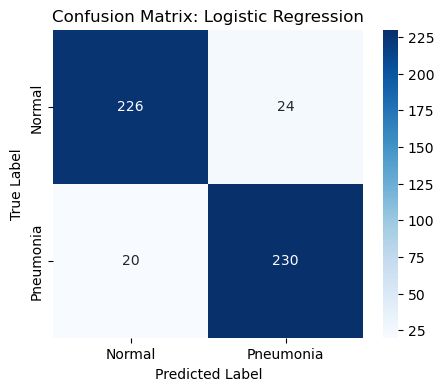

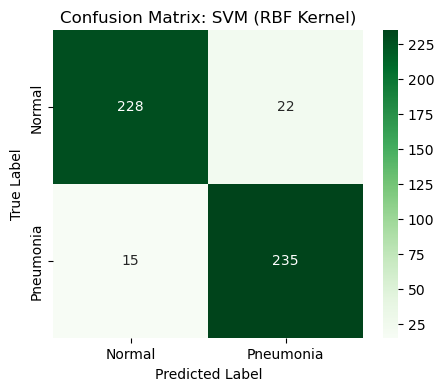

In [2]:
import seaborn as sns

#LR heatmap
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#SVM heatmap
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix: SVM (RBF Kernel)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## Creating ROC curve

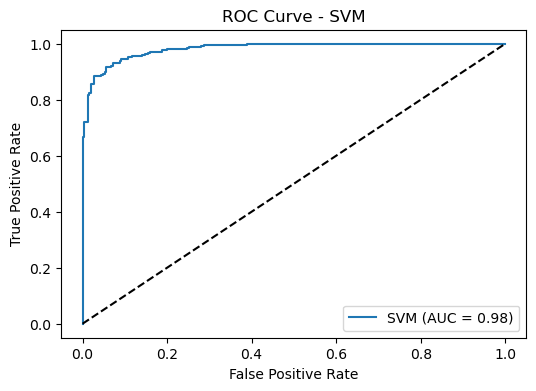

In [9]:
#ROC curve 
##AUC is area under the curve shows how well the model is working, 0.98 means that 98% of the time the model will predict correctly pneumonia vs normal

from sklearn.metrics import roc_curve, auc
#returns confident score
y_scores_svm = svm.decision_function(X_test_pca)

#false positive rate (FPR) and true positive rate (TPR) 
fpr, tpr, _ = roc_curve(y_test, y_scores_svm)
#computes area underneath curve
roc_auc = auc(fpr, tpr)


#plots the roc curve 
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc="lower right")

## Creating Precision-Recall curve

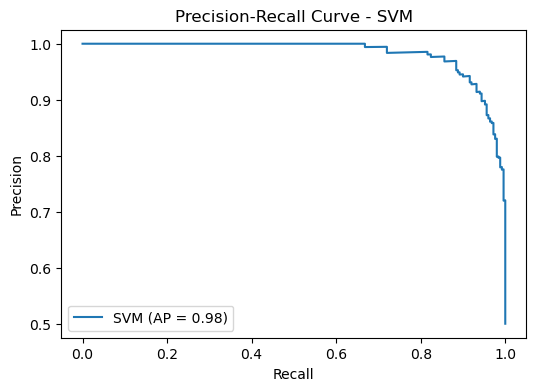

In [8]:
#how many were pneumonia cases were there over how many did the model identify correctly
#AP (Average Precision) tells you how good your model is at correctly finding pneumonia cases while making as few mistakes as possible (high precision + high recall)

from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score
#calculates the precision and recall 
precision, recall, _ = precision_recall_curve(y_test, y_scores_svm)
#area underneath curve 
ap_score = average_precision_score(y_test, y_scores_svm)

#plot recall & precision curve 
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"SVM (AP = {ap_score:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM")
plt.legend()

## Comparing model accuracy

Text(0.5, 1.0, 'Model Accuracy Comparison')

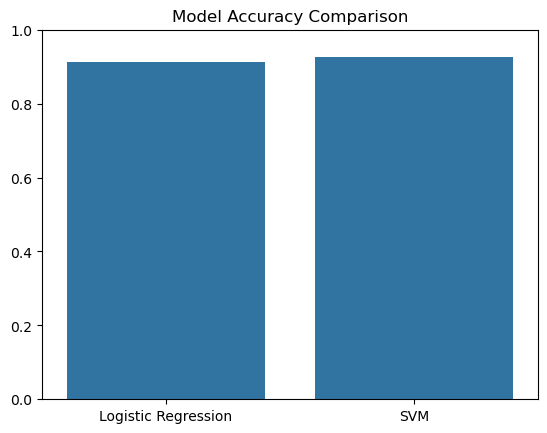

In [14]:
#Both Logistic Regression and SVM have really similar accuracy .91 vs .92
models = ["Logistic Regression", "SVM"]
scores = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_svm)]

sns.barplot(x=models, y=scores)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")